In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

C:\Users\Riyad\AppData\Roaming\Python\Python310\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
C:\Users\Riyad\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Device: cuda


In [4]:
# Load data with NLP features
df = pd.read_csv('C:/Users/Riyad/projects/fake_news/step7_nlp_features.csv')

train_df = pd.read_csv('C:/Users/Riyad/projects/fake_news/train_final.csv')
val_df = pd.read_csv('C:/Users/Riyad/projects/fake_news/val_final.csv')
test_df = pd.read_csv('C:/Users/Riyad/projects/fake_news/test_final.csv')

# NLP feature columns
nlp_cols = ['token_count', 'noun_count', 'verb_count', 
            'adjective_count', 'unique_pos_count', 'ner_count', 'ner_ratio']

# Combine text first
train_df['text'] = train_df['headline'].fillna('') + ' ' + train_df['content'].fillna('')
val_df['text'] = val_df['headline'].fillna('') + ' ' + val_df['content'].fillna('')
test_df['text'] = test_df['headline'].fillna('') + ' ' + test_df['content'].fillna('')
df['text'] = df['headline'].fillna('') + ' ' + df['content'].fillna('')

# Merge on text
train_df = train_df.merge(df[['text'] + nlp_cols].drop_duplicates('text'), on='text', how='left')
val_df = val_df.merge(df[['text'] + nlp_cols].drop_duplicates('text'), on='text', how='left')
test_df = test_df.merge(df[['text'] + nlp_cols].drop_duplicates('text'), on='text', how='left')

# Fill NaN
train_df[nlp_cols] = train_df[nlp_cols].fillna(0)
val_df[nlp_cols] = val_df[nlp_cols].fillna(0)
test_df[nlp_cols] = test_df[nlp_cols].fillna(0)

# Label encoding
label2id = {'authentic': 0, 'fake': 1, 'ai_fake': 2}
id2label = {0: 'authentic', 1: 'fake', 2: 'ai_fake'}

train_df['label_id'] = train_df['label'].map(label2id)
val_df['label_id'] = val_df['label'].map(label2id)
test_df['label_id'] = test_df['label'].map(label2id)

train_df = train_df.dropna(subset=['text', 'label_id'])
val_df = val_df.dropna(subset=['text', 'label_id'])
test_df = test_df.dropna(subset=['text', 'label_id'])

print(" Data loaded!")
print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")

 Data loaded!
Train: 10500
Val:   2250
Test:  2250


In [5]:
from sklearn.preprocessing import StandardScaler

# Normalize NLP features
scaler = StandardScaler()
train_df[nlp_cols] = scaler.fit_transform(train_df[nlp_cols])
val_df[nlp_cols] = scaler.transform(val_df[nlp_cols])
test_df[nlp_cols] = scaler.transform(test_df[nlp_cols])

# Load BanglaBERT tokenizer
print("Loading BanglaBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("csebuetnlp/banglabert")
print(" Tokenizer loaded!")

# Fusion Dataset class
class FusionDataset(Dataset):
    def __init__(self, texts, metadata, labels, tokenizer, max_len=128):
        self.texts = texts
        self.metadata = metadata
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'metadata': torch.tensor(
                self.metadata[idx], dtype=torch.float
            ),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = FusionDataset(
    train_df['text'].values,
    train_df[nlp_cols].values,
    train_df['label_id'].values,
    tokenizer
)
val_dataset = FusionDataset(
    val_df['text'].values,
    val_df[nlp_cols].values,
    val_df['label_id'].values,
    tokenizer
)
test_dataset = FusionDataset(
    test_df['text'].values,
    test_df[nlp_cols].values,
    test_df['label_id'].values,
    tokenizer
)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

print(" Datasets ready!")
print(f"Train batches: {len(train_loader)}")

Loading BanglaBERT tokenizer...
 Tokenizer loaded!
 Datasets ready!
Train batches: 657


In [6]:
# Metadata Fusion Model
class MetadataFusionModel(nn.Module):
    def __init__(self, metadata_dim, num_classes=3, dropout=0.3):
        super(MetadataFusionModel, self).__init__()
        
        # BanglaBERT encoder
        self.bert = AutoModel.from_pretrained("csebuetnlp/banglabert")
        bert_dim = self.bert.config.hidden_size  # 768
        
        # Metadata MLP
        self.metadata_mlp = nn.Sequential(
            nn.Linear(metadata_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Fusion classifier
        self.classifier = nn.Sequential(
            nn.Linear(bert_dim + 64, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, input_ids, attention_mask, metadata):
        # BERT output
        bert_out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_output = bert_out.last_hidden_state[:, 0, :]  # CLS token
        
        # Metadata output
        meta_output = self.metadata_mlp(metadata)
        
        # Fusion
        combined = torch.cat([cls_output, meta_output], dim=1)
        
        return self.classifier(combined)

# Initialize model
model = MetadataFusionModel(
    metadata_dim=len(nlp_cols)
).to(device)

print(" Metadata Fusion Model ready!")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Optimizer
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_loader) * 3
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)
criterion = nn.CrossEntropyLoss()

print(f"Total training steps: {total_steps}")

 Metadata Fusion Model ready!
Total parameters: 110,241,283
Total training steps: 1971


In [7]:
# Training function
def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    
    for batch in loader:
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        metadata = batch['metadata'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(input_ids, attention_mask, metadata)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
    
    return total_loss / len(loader)

# Evaluation function
def evaluate(model, loader):
    model.eval()
    preds = []
    true_labels = []
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            metadata = batch['metadata'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids, attention_mask, metadata)
            pred = outputs.argmax(dim=1)
            preds.extend(pred.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    return preds, true_labels

# Train for 3 epochs
print("Training started!")
best_f1 = 0

for epoch in range(3):
    print(f"\nEpoch {epoch+1}/3")
    
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion)
    print(f"Train Loss: {train_loss:.4f}")
    
    val_preds, val_true = evaluate(model, val_loader)
    val_f1 = f1_score(val_true, val_preds, average='macro')
    print(f"Val Macro F1: {val_f1*100:.2f}%")
    
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(
            model.state_dict(),
            'C:/Users/Riyad/projects/fake_news/fusion_best.pt'
        )
        print(f"Best model saved!")

print(f"\nBest Val F1: {best_f1*100:.2f}%")

Training started!

Epoch 1/3
Train Loss: 0.3807
Val Macro F1: 89.37%
Best model saved!

Epoch 2/3
Train Loss: 0.2195
Val Macro F1: 91.71%
Best model saved!

Epoch 3/3
Train Loss: 0.1560
Val Macro F1: 92.03%
Best model saved!

Best Val F1: 92.03%


In [8]:
# Load best model
model.load_state_dict(torch.load(
    'C:/Users/Riyad/projects/fake_news/fusion_best.pt'
))

# Test evaluation
test_preds, test_true = evaluate(model, test_loader)

print("=== Metadata Fusion Model Test Results ===")
print(classification_report(
    test_true,
    test_preds,
    target_names=['authentic', 'fake', 'ai_fake']
))

test_f1 = f1_score(test_true, test_preds, average='macro')
print(f"Test Macro F1: {test_f1*100:.2f}%")

=== Metadata Fusion Model Test Results ===
              precision    recall  f1-score   support

   authentic       0.86      0.91      0.89       750
        fake       0.89      0.85      0.87       750
     ai_fake       1.00      0.99      0.99       750

    accuracy                           0.92      2250
   macro avg       0.92      0.92      0.92      2250
weighted avg       0.92      0.92      0.92      2250

Test Macro F1: 91.69%


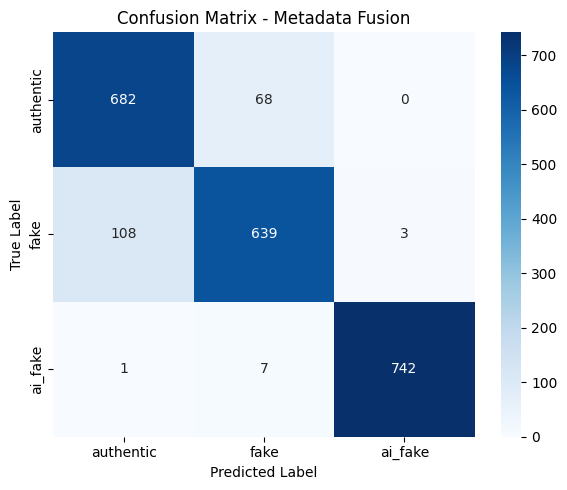

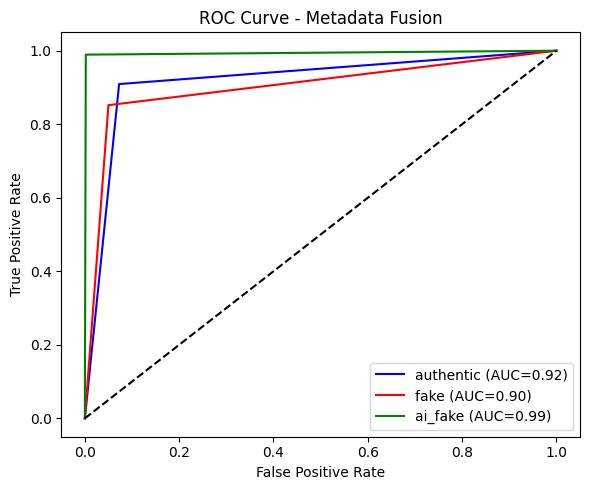

 Confusion Matrix & ROC Curve saved!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

id2label = {0: 'authentic', 1: 'fake', 2: 'ai_fake'}
label_names = ['authentic', 'fake', 'ai_fake']

# ── Confusion Matrix ──
fig1, ax1 = plt.subplots(1, 1, figsize=(6, 5))
cm = confusion_matrix(test_true, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names, ax=ax1)
ax1.set_title('Confusion Matrix - Metadata Fusion')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('C:/Users/Riyad/projects/fake_news/cm_fusion.png', dpi=300, bbox_inches='tight')
plt.show()

# ── ROC Curve ──
y_true_bin = label_binarize(test_true, classes=[0, 1, 2])
y_pred_bin = label_binarize(test_preds, classes=[0, 1, 2])

fig2, ax2 = plt.subplots(1, 1, figsize=(6, 5))
colors = ['blue', 'red', 'green']

for i, (cls, color) in enumerate(zip(label_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color=color, label=f'{cls} (AUC={roc_auc:.2f})')

ax2.plot([0, 1], [0, 1], 'k--')
ax2.set_title('ROC Curve - Metadata Fusion')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc='lower right')
plt.tight_layout()
plt.savefig('C:/Users/Riyad/projects/fake_news/roc_fusion.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Confusion Matrix & ROC Curve saved!")